In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import iris dataset from kaggle link
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
# read the dataset into a pandas dataframe
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [61]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])

In [62]:
df=df[df['species']!=0][['sepal_length','sepal_width','species']]

In [63]:
df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


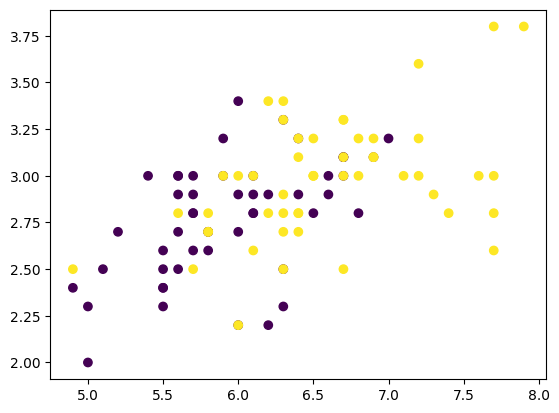

In [64]:
import seaborn as sns
plt.scatter(df['sepal_length'],df['sepal_width'],c=df['species'])

In [65]:
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [66]:
df_train.head()

,sepal_length,sepal_width,species
86,6.7,3.1,1
148,6.2,3.4,2
132,6.4,2.8,2
118,7.7,2.6,2
109,7.2,3.6,2


In [67]:
X_test=df_test[['sepal_length','sepal_width']].values
y_test=df_test['species'].values

## bagging

In [68]:
df_bag=df_train.sample(8,replace=True)

In [69]:
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_length,sepal_width,species
132,6.4,2.8,2
86,6.7,3.1,1
109,7.2,3.6,2
63,6.1,2.9,1
66,5.6,3.0,1
102,7.1,3.0,2
109,7.2,3.6,2
132,6.4,2.8,2


In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [71]:
dt_bag1=DecisionTreeClassifier()

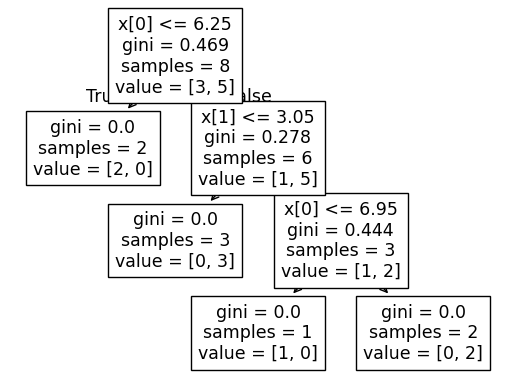

Accuracy: 0.6


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


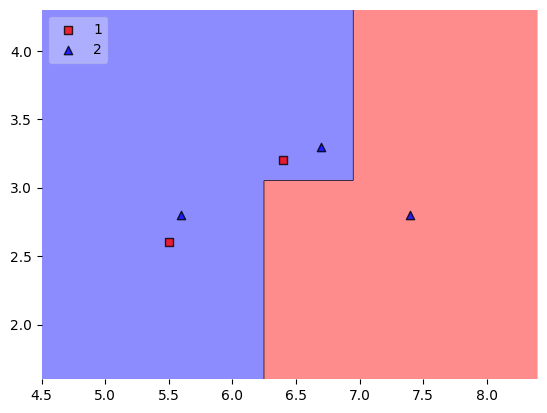

In [72]:
evaluate(dt_bag1,X,y)

In [73]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    y_pred=clf.predict(X_test)
    print("Accuracy:",accuracy_score(y_test,y_pred))
    plot_decision_regions(X_test,y_test,clf=clf,legend=2,colors='red,blue')
    

In [74]:
dt_bag2=df_train.sample(10,replace=True) 
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

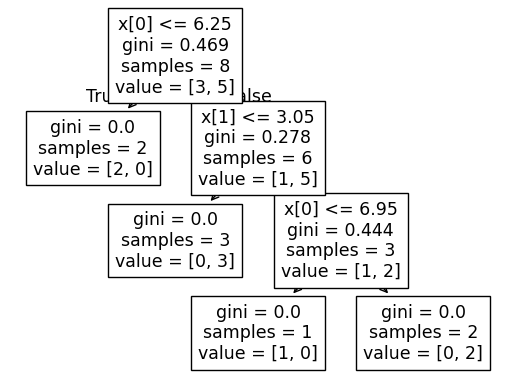

Accuracy: 0.6


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


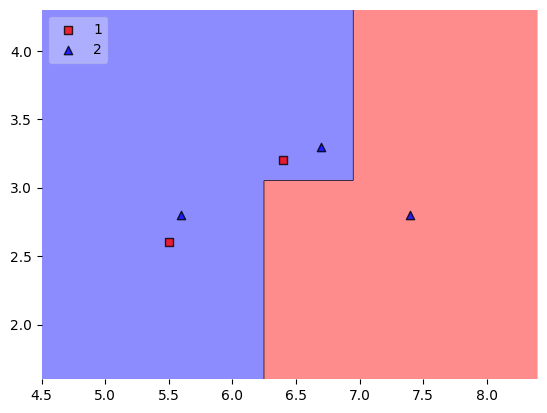

In [75]:
evaluate(dt_bag1,X,y)

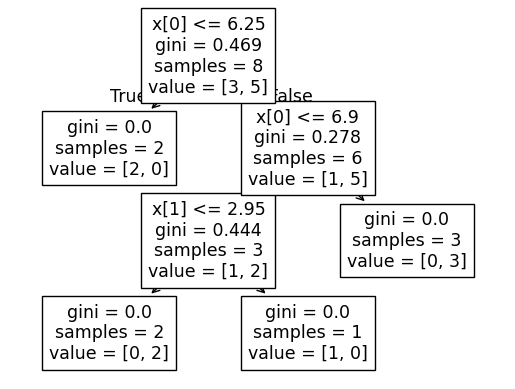

Accuracy: 0.6


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


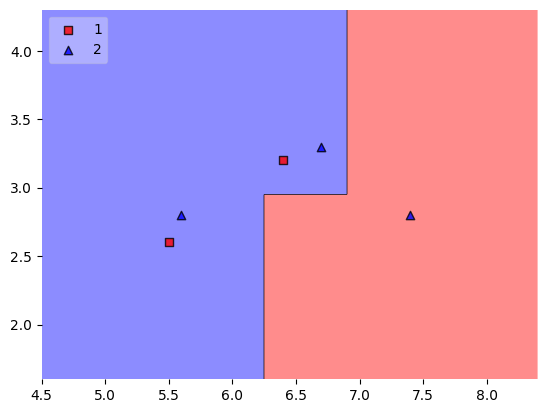

In [76]:
dt_bag3=DecisionTreeClassifier(max_depth=3)
evaluate(dt_bag3,X,y)

In [ ]:
df_test
print("Predictor 1",dt_bag1.predict(np.array([5.0,3.0]).reshape(1,-1))) 

Predictor 1 [1]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
x=print("helo")
print(x)

helo
None
